In [134]:
import wetter_api as wt
import waldbrand
import model_eval as me
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.utils import shuffle
from sklearn.preprocessing import normalize
# from sklearn.linear_model import LinearRegression, Ridge, Lasso
# from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
# from sklearn.svm import SVR
# from sklearn.metrics import mean_squared_error, r2_score
import logging
import pandas as pd
import common_paths
import seaborn as sb
import plotly.express as pl
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np
from sklearn.preprocessing import normalize
from sklearn.ensemble import GradientBoostingRegressor

In [167]:
parameter_list = [
    wt.DwdObservationParameter.MONTHLY.PRECIPITATION_HEIGHT,
    wt.DwdObservationParameter.MONTHLY.CLIMATE_SUMMARY.WIND_FORCE_BEAUFORT,
    wt.DwdObservationParameter.MONTHLY.TEMPERATURE_AIR_MAX_200,
]
# Dictionary with short names as keys and full names as values
shortname_to_state = {
    "BW": "Baden-Württemberg",
    "BY": "Bayern",
    "BE": "Berlin",
    "BB": "Brandenburg",
    "HB": "Bremen",
    "HH": "Hamburg",
    "HE": "Hessen",
    "MV": "Mecklenburg-Vorpommern",
    "NI": "Niedersachsen",
    "NW": "Nordrhein-Westfalen",
    "RP": "Rheinland-Pfalz",
    "SL": "Saarland",
    "SN": "Sachsen",
    "ST": "Sachsen-Anhalt",
    "SH": "Schleswig-Holstein",
    "TH": "Thüringen",
}

# Example usage
shortname = "BB"
state = shortname_to_state.get(shortname)

In [168]:
#nr = me.prepare_data(parameter_list, state, "nr")
data = me.prepare_data(parameter_list, state)
data

,Year,Month,station_id,pr,sfcWind,tasmax,nFires,area
2,1996,1,00691,2.9,5.148909,283.25,0.0,0.0
3,1996,1,00701,1.5,4.718405,283.55,0.0,0.0
4,1997,1,00691,2.8,3.011675,281.65,0.0,0.0
5,1997,1,00701,1.8,3.011675,279.75,0.0,0.0
6,1998,1,00691,68.0,4.898141,285.65,0.0,0.0
...,...,...,...,...,...,...,...,...
666,2020,12,00701,92.3,4.562983,284.65,0.0,0.0
667,2021,12,00691,63.8,3.791684,286.75,0.0,0.0
668,2021,12,00701,79.3,4.920766,285.95,0.0,0.0
669,2022,12,00691,82.4,3.404212,289.15,0.0,0.0


In [169]:
future_bb_weather = pd.read_csv(common_paths.DATA.joinpath("dwd/future_Brandenburg.csv"))
future_bb_weather.drop(columns=['Unnamed: 0', 'Bundesland'], inplace = True)
#adjust precipitation to same unit
future_bb_weather['pr'] = future_bb_weather['pr'] * 3600 * 24 * 30
future_bb_weather

,pr,tasmax,sfcWind,Year,Month
0,51.580644,278.43063,4.900000,2024,1
1,54.774196,278.38547,4.761291,2024,1
2,63.967742,278.19840,4.422581,2024,1
3,47.709679,278.55966,4.416129,2024,1
4,47.709679,278.54030,4.367742,2024,1
...,...,...,...,...,...
70390,41.612901,274.10160,4.516129,2054,1
70391,51.967742,273.57257,5.196774,2054,1
70392,51.967742,273.62740,5.316129,2054,1
70393,45.483872,273.60483,5.216129,2054,1


In [170]:
#future_bb_weather = me.grid_means(future_brandenburg_weather)

In [171]:
print('means: \n' , data[['pr', 'sfcWind', 'tasmax']].mean())
print('\n variance: \n', data[['pr', 'sfcWind', 'tasmax']].var())
print('\n std: \n' , data[['pr', 'sfcWind', 'tasmax']].std())
print('\n min: \n', data[['pr', 'sfcWind', 'tasmax']].min())
print('\n max: \n', data[['pr', 'sfcWind', 'tasmax']].max())

means: 
 pr          58.774173
sfcWind      4.627501
tasmax     294.152362
dtype: float64

 variance: 
 pr         1233.653591
sfcWind       1.002160
tasmax       62.249348
dtype: float64

 std: 
 pr         35.123405
sfcWind     1.001080
tasmax      7.889826
dtype: float64

 min: 
 pr           1.500000
sfcWind      2.709396
tasmax     276.350000
dtype: float64

 max: 
 pr         259.500000
sfcWind      9.179028
tasmax     310.550000
dtype: float64


In [172]:
print('means: \n' , future_bb_weather[['pr', 'sfcWind', 'tasmax']].mean())
print('\n variance: \n' , future_bb_weather[['pr', 'sfcWind', 'tasmax']].var())
print('\n std: \n' , future_bb_weather[['pr', 'sfcWind', 'tasmax']].std())
print('\n min: \n' , future_bb_weather[['pr', 'sfcWind', 'tasmax']].min())
print('\n max: \n' , future_bb_weather[['pr', 'sfcWind', 'tasmax']].max())

means: 
 pr          47.990091
sfcWind      3.670293
tasmax     287.263343
dtype: float64

 variance: 
 pr         738.434263
sfcWind      0.429837
tasmax      64.163249
dtype: float64

 std: 
 pr         27.174147
sfcWind     0.655619
tasmax      8.010197
dtype: float64

 min: 
 pr           0.387097
sfcWind      1.916129
tasmax     270.556460
dtype: float64

 max: 
 pr         257.599984
sfcWind      7.396774
tasmax     302.598400
dtype: float64


In [173]:
data

,Year,Month,station_id,pr,sfcWind,tasmax,nFires,area
2,1996,1,00691,2.9,5.148909,283.25,0.0,0.0
3,1996,1,00701,1.5,4.718405,283.55,0.0,0.0
4,1997,1,00691,2.8,3.011675,281.65,0.0,0.0
5,1997,1,00701,1.8,3.011675,279.75,0.0,0.0
6,1998,1,00691,68.0,4.898141,285.65,0.0,0.0
...,...,...,...,...,...,...,...,...
666,2020,12,00701,92.3,4.562983,284.65,0.0,0.0
667,2021,12,00691,63.8,3.791684,286.75,0.0,0.0
668,2021,12,00701,79.3,4.920766,285.95,0.0,0.0
669,2022,12,00691,82.4,3.404212,289.15,0.0,0.0


In [174]:
data.dropna(inplace = True)

In [175]:
data['Year'].count()

635

<Axes: >

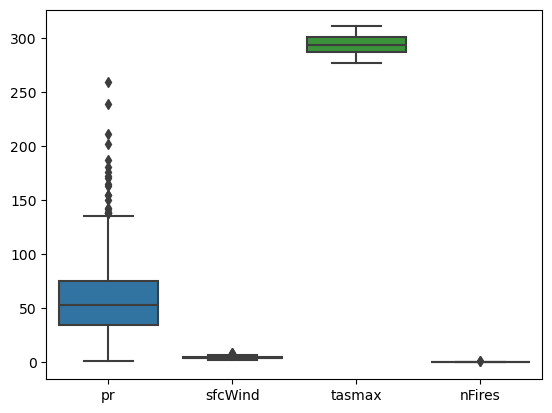

In [176]:
sb.boxplot(data[['pr', 'sfcWind', 'tasmax', 'area', 'nFires']])

<Axes: >

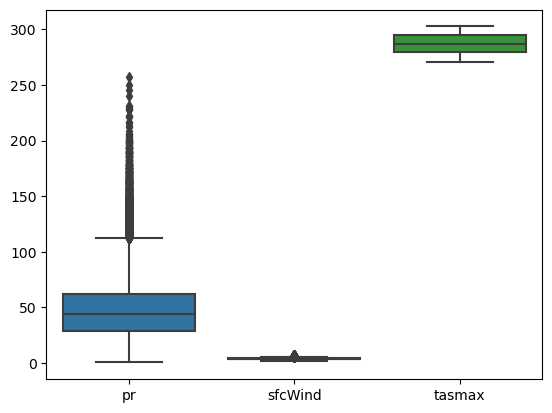

In [177]:
sb.boxplot(future_bb_weather[['pr', 'sfcWind', 'tasmax']])

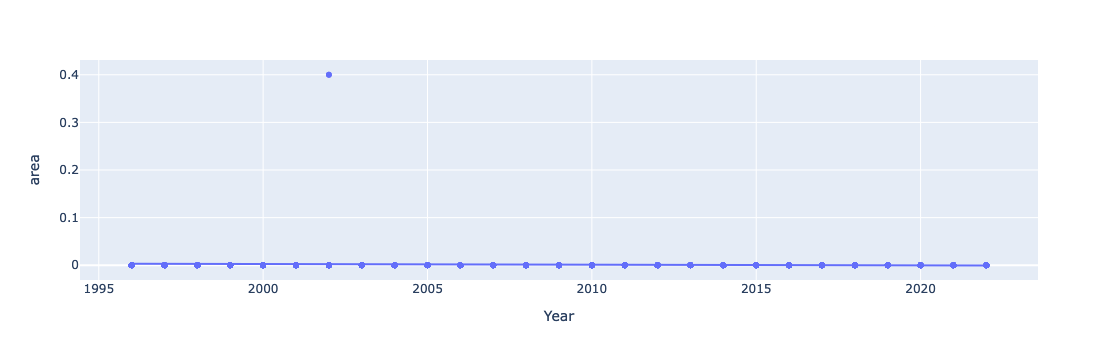

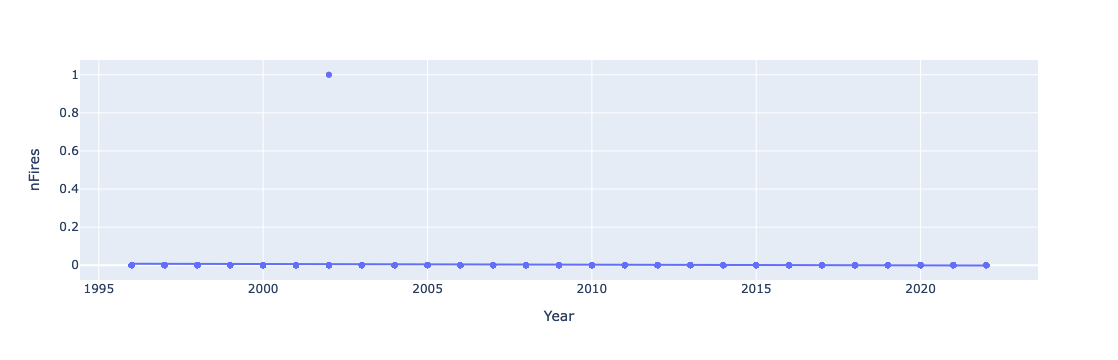

In [178]:
fig1 = pl.scatter(data, x='Year', y='area', trendline="ols")
fig2 = pl.scatter(data, x='Year', y='nFires', trendline="ols")
fig1.show()
fig2.show()

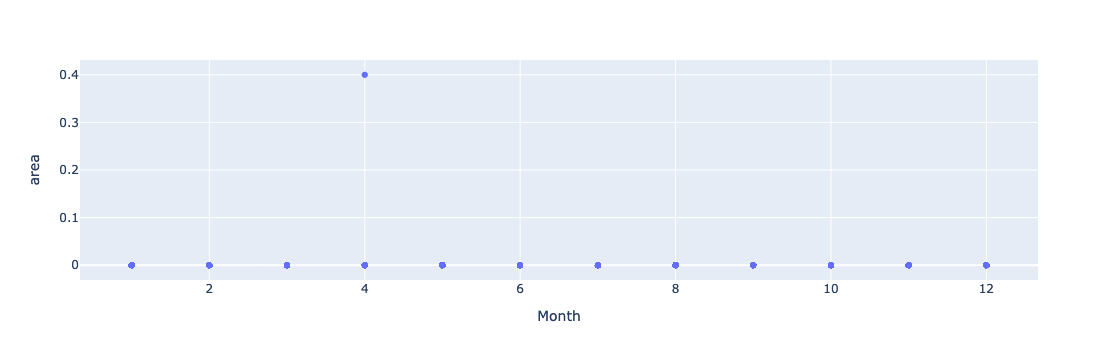

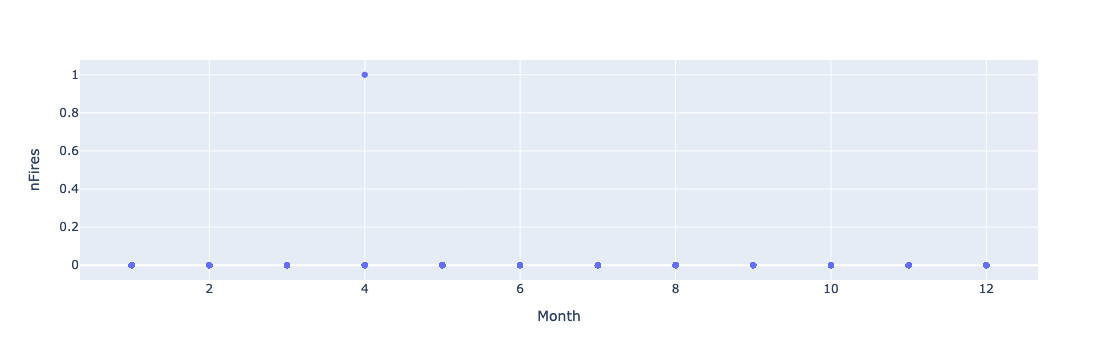

In [179]:
fig1 = pl.scatter(data, x='Month', y='area')
fig2 = pl.scatter(data, x='Month', y='nFires')
fig1.show()
fig2.show()

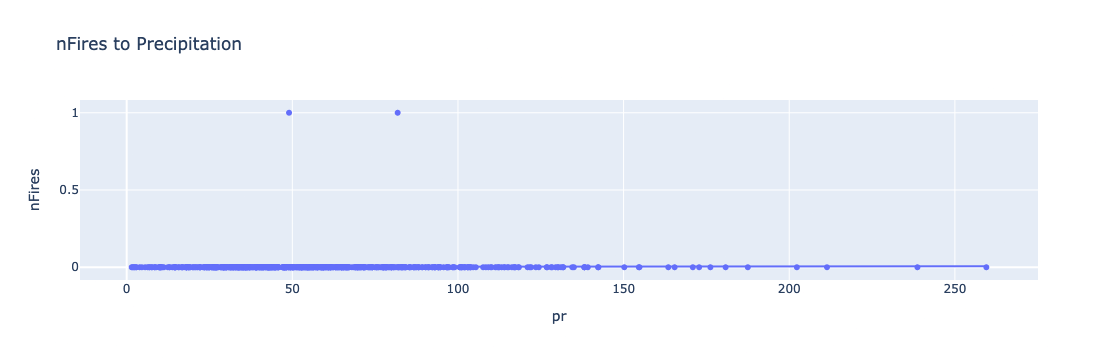

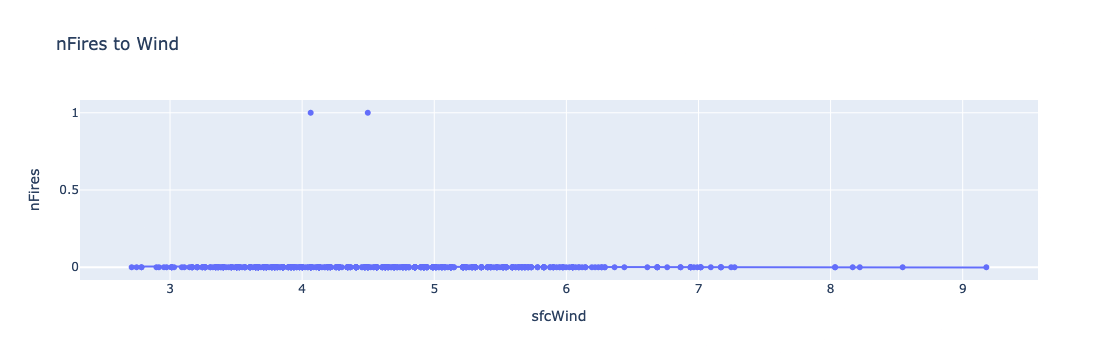

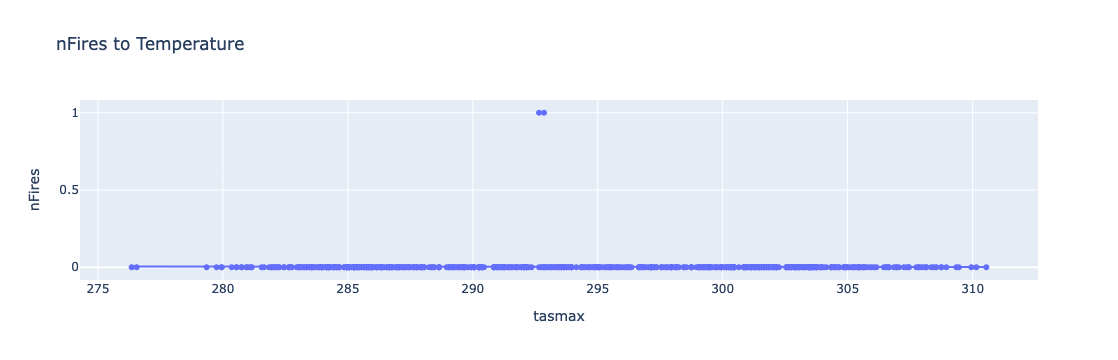

In [180]:
fig1 = pl.scatter(data, x = "pr", y = 'nFires', trendline="ols", title='nFires to Precipitation')
fig2 = pl.scatter(data, x = "sfcWind", y = 'nFires', trendline="ols", title='nFires to Wind')
fig3 = pl.scatter(data, x = "tasmax", y = 'nFires', trendline="ols", title='nFires to Temperature')

fig1.show()
fig2.show()
fig3.show()

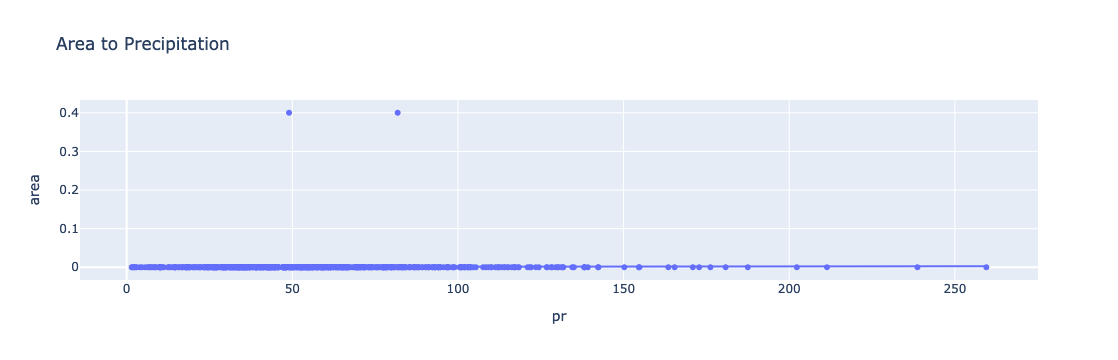

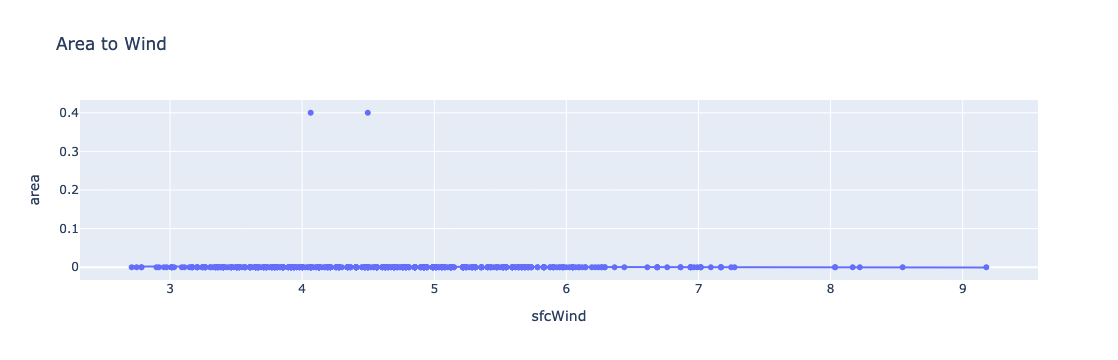

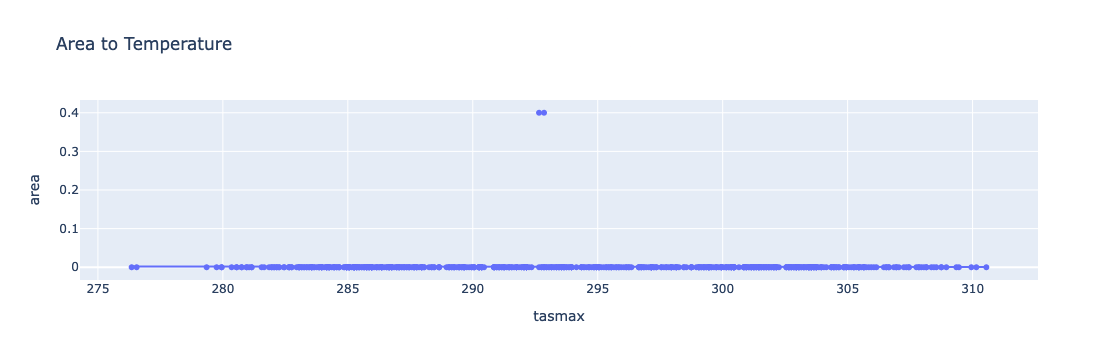

In [181]:
fig1 = pl.scatter(data, x = "pr", y = 'area', trendline="ols", title='Area to Precipitation')
fig2 = pl.scatter(data, x = "sfcWind", y = 'area', trendline="ols", title='Area to Wind')
fig3 = pl.scatter(data, x = "tasmax", y = 'area', trendline="ols", title='Area to Temperature')

fig1.show()
fig2.show()
fig3.show()

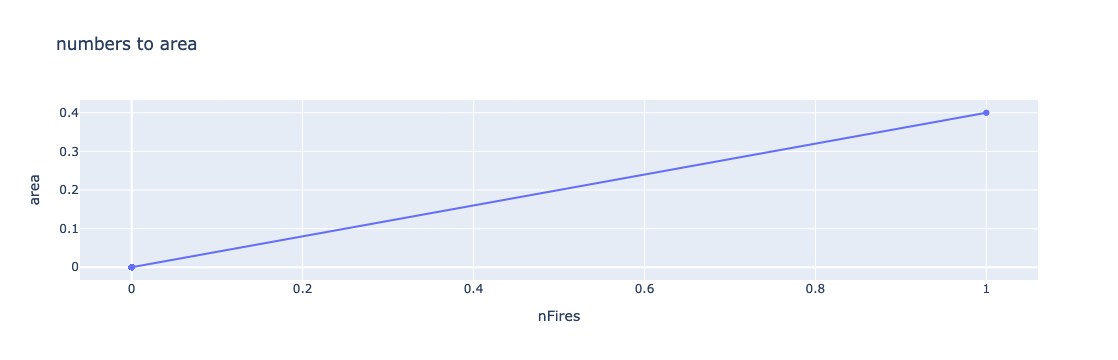

In [182]:
fig1 = pl.scatter(data, x = "nFires", y = 'area', trendline="ols", title='numbers to area')
fig1.show()

In [183]:
data

,Year,Month,station_id,pr,sfcWind,tasmax,nFires,area
2,1996,1,00691,2.9,5.148909,283.25,0.0,0.0
3,1996,1,00701,1.5,4.718405,283.55,0.0,0.0
4,1997,1,00691,2.8,3.011675,281.65,0.0,0.0
5,1997,1,00701,1.8,3.011675,279.75,0.0,0.0
6,1998,1,00691,68.0,4.898141,285.65,0.0,0.0
...,...,...,...,...,...,...,...,...
666,2020,12,00701,92.3,4.562983,284.65,0.0,0.0
667,2021,12,00691,63.8,3.791684,286.75,0.0,0.0
668,2021,12,00701,79.3,4.920766,285.95,0.0,0.0
669,2022,12,00691,82.4,3.404212,289.15,0.0,0.0


In [184]:
#normalize(data[['pr', 'sfcWind', 'tasmax']])
#normalize(future_bb_weather[['pr', 'sfcWind', 'tasmax']])

<Axes: >

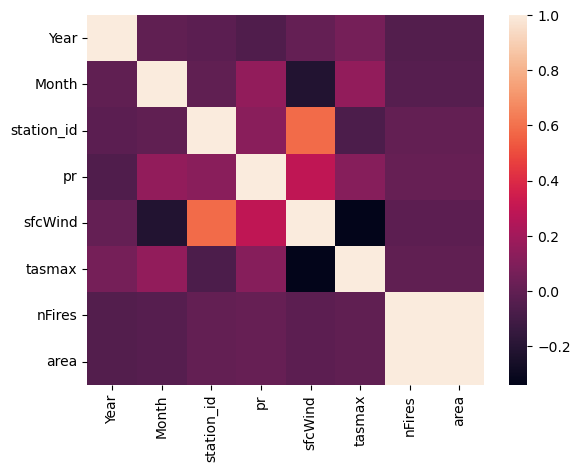

In [185]:
'''
Achtung hier lineare korrelationen -> hoch heißt korrelation ist stark aber niedrig kann andere art von korrelation sein
(BSP regen zu feuer)
'''
sb.heatmap(data.corr(numeric_only=False))

In [186]:
str_parameter_list = [str(param) for param in parameter_list]
dates = data[['Year', 'Month']]
feature_list = ["sfcWind", "pr", "tasmax"]

X_nr = data[feature_list]
y_nr = data["nFires"]

#X, y, dates = shuffle(X, y, dates, random_state=42)
X_train_nr, X_test_nr, y_train_nr, y_test_nr, dates_train, dates_test = train_test_split(X_nr, y_nr, dates, test_size=0.2, random_state=42)

In [187]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
import numpy as np
X_scaled_train = RobustScaler().fit_transform(X_train_nr)
X_scaled_test = RobustScaler().fit_transform(X_test_nr)

In [188]:
param_grid = {
    "n_estimators": [70, 80, 100],
    "max_depth": [3, 5, 6],  # Smaller range for max depth
    "min_samples_leaf": [2, 3, 5],
    "min_samples_split": [5, 7, 8]
}
gbr = GradientBoostingRegressor()

grid_search = GridSearchCV(
    estimator=gbr, param_grid=param_grid, cv=5, scoring="neg_mean_squared_error"
)
#searching for the right parameters using random Forest on a 5-fold Cross Validation (cv) and the nmse
nr_grid = grid_search.fit(X_scaled_train, y_train_nr)

# saving best parameters and model
nr_best_params = grid_search.best_params_
nr_best_model = grid_search.best_estimator_
print(nr_best_params)
print(nr_best_model)

{'max_depth': 6, 'min_samples_leaf': 5, 'min_samples_split': 8, 'n_estimators': 70}
GradientBoostingRegressor(max_depth=6, min_samples_leaf=5, min_samples_split=8,
                          n_estimators=70)


In [198]:
#predict 'Anzahl Waldbrände' with the model
y_pred_nr = nr_best_model.predict(X_scaled_test)


mse = mean_squared_error(y_test_nr, y_pred_nr)
r2 = r2_score(y_test_nr, y_pred_nr)
mae = mean_absolute_error(y_test_nr, y_pred_nr)

print(f"MSE: {mse}")
print(f"R2 Score: {r2}")
print(f"MAE: {mae}")
print(y_pred_nr)

MSE: 0.00919876164087497
R2 Score: -0.17751449607676473
MAE: 0.013688134706278714
[ 3.82500302e-01 -1.67338119e-03  9.14907437e-05  2.68829829e-03
  1.42030542e-03  9.71948658e-05  1.95865950e-04 -7.94994679e-04
  3.32732091e-04 -1.36902551e-03 -9.24931550e-04 -5.75442445e-04
  3.20493626e-03 -2.43945376e-02 -2.51881292e-05  1.87722124e-04
 -6.60899983e-05 -1.69928940e-04 -1.57248513e-03  1.55582190e-04
  2.71984594e-04 -3.95321105e-03  3.74060217e-04 -4.91555778e-04
  5.02481261e-04 -2.46701584e-02  7.07881016e-05 -8.71999017e-03
  4.96468075e-02 -1.37751032e-03  7.99666748e-05 -2.10540018e-04
  3.23181835e-04  1.98317617e-03  9.48465767e-04 -7.55707050e-03
 -2.54873373e-04  2.48422441e-04  1.86019108e-04  4.28750282e-04
  5.90570021e-04 -1.85368584e-03  9.56692960e-04  1.47013876e-04
 -7.45059034e-04  5.86299382e-02 -3.86964580e-03 -1.61267444e-03
  3.85088165e-04  3.94764055e-04  5.43941718e-04 -2.37395786e-03
  3.10628771e-04 -2.20986591e-03  6.15381268e-04 -1.91591352e-03
  1.1232

In [190]:
feature_list = ["sfcWind", "pr", "tasmax"]

X_area = data[feature_list]
y_area = data['area']

X_train_area, X_test_area, y_train_area, y_test_area, dates_train, dates_test = train_test_split(X_area, y_area, dates, test_size=0.2, random_state=42)

In [191]:
param_grid = {
    "n_estimators": [65, 75, 85],
    "max_depth": [3, 5, 6],  # Smaller range for max depth
    "min_samples_leaf": [1, 2, 3],
    "min_samples_split": [6, 7, 8]
}
gbr = GradientBoostingRegressor()

grid_search = GridSearchCV(
    estimator=gbr, param_grid=param_grid, cv=5, scoring="neg_mean_squared_error"
)
#searching for the right parameters using random Forest on a 5-fold Cross Validation (cv) and the nmse
area_grid = grid_search.fit(X_train_area, y_train_area)

# saving best parameters and model
area_best_params = grid_search.best_params_
area_best_model = grid_search.best_estimator_
print(area_best_params)
print(area_best_model)

{'max_depth': 6, 'min_samples_leaf': 3, 'min_samples_split': 6, 'n_estimators': 65}
GradientBoostingRegressor(max_depth=6, min_samples_leaf=3, min_samples_split=6,
                          n_estimators=65)


In [192]:
y_pred_area = area_best_model.predict(X_test_area)


mse = mean_squared_error(y_test_area, y_pred_area)
r2 = r2_score(y_test_area, y_pred_area)
mae = mean_absolute_error(y_test_area, y_pred_area)

print(f"MSE: {mse}")
print(f"R2 Score: {r2}")
print(f"MAE: {mae}")

MSE: 0.0015023112898648887
R2 Score: -0.20192355130113016
MAE: 0.00584409192182922


In [193]:
from sklearn.neural_network import MLPRegressor
regr_nr = MLPRegressor(random_state=1, max_iter=50000).fit(X_scaled_train, y_train_nr)
#regr_area = MLPRegressor(random_state=10, max_iter=500, alpha=0.1).fit(X_train_area, y_train_area)
regr_nr.predict(X_scaled_test)
regr_nr.score(X_scaled_test, y_test_nr)

-0.10161528173876855

In [194]:
regr_area = MLPRegressor(random_state=10, max_iter=5000).fit(X_scaled_train, y_train_area)
regr_nr.predict(X_scaled_test)
regr_nr.score(X_scaled_test, y_test_area)

-0.6091568235963671

In [195]:
me.evaluate_models(X_scaled_train, X_scaled_test, y_train_nr, y_test_nr)

{'Linear Regression': {'model': LinearRegression(),
  'mse': 0.007847499709738708,
  'r2_score': -0.004542244590282518},
 'Ridge Regression': {'model': Ridge(),
  'mse': 0.007847524555824098,
  'r2_score': -0.004545425086403654},
 'Lasso Regression': {'model': Lasso(),
  'mse': 0.007846890693781387,
  'r2_score': -0.004464285714285587},
 'Decision Tree Regression': {'model': DecisionTreeRegressor(),
  'mse': 0.007874015748031496,
  'r2_score': -0.007936507936507908},
 'Random Forest Regression': {'model': RandomForestRegressor(),
  'mse': 0.008256692913385827,
  'r2_score': -0.056922222222222096},
 'Support Vector Regression': {'model': SVR(),
  'mse': 0.013816176452167516,
  'r2_score': -0.7685802380715065},
 'Gradient Boosting Regression': {'model': GradientBoostingRegressor(),
  'mse': 0.01498684401308172,
  'r2_score': -0.918434976880913}}

In [196]:
me.evaluate_models(X_scaled_train, X_scaled_test, y_train_area, y_test_area)

{'Linear Regression': {'model': LinearRegression(),
  'mse': 0.0012555999535581938,
  'r2_score': -0.00454224459028274},
 'Ridge Regression': {'model': Ridge(),
  'mse': 0.0012556039289318562,
  'r2_score': -0.004545425086403876},
 'Lasso Regression': {'model': Lasso(),
  'mse': 0.0012555025110050232,
  'r2_score': -0.0044642857142862535},
 'Decision Tree Regression': {'model': DecisionTreeRegressor(),
  'mse': 0.0012598425196850395,
  'r2_score': -0.007936507936507908},
 'Random Forest Regression': {'model': RandomForestRegressor(),
  'mse': 0.0013102362204724413,
  'r2_score': -0.048253968253968216},
 'Support Vector Regression': {'model': SVR(),
  'mse': 0.008030873742078087,
  'r2_score': -5.425097350494913},
 'Gradient Boosting Regression': {'model': GradientBoostingRegressor(),
  'mse': 0.0023978950423183118,
  'r2_score': -0.9184349770611131}}

In [197]:
from sklearn.neighbors import KNeighborsRegressor
model = KNeighborsRegressor(n_neighbors=2).fit(X_scaled_train, y_train_nr)
y_pred = model.predict(X_scaled_test)
mse = mean_squared_error(y_test_nr, y_pred)
r2 = r2_score(y_test_nr, y_pred)
print(r2, mse)

-0.25992063492063466 0.00984251968503937


In [28]:
nr_predictions = nr_best_model.predict(future_bb_weather[feature_list])
area_predictions = area_best_model.predict(future_bb_weather[feature_list])

final_predictions = pd.DataFrame({'Year': future_bb_weather['Year'], 'Month': future_bb_weather['Month'], 'tasmax': future_bb_weather['tasmax'], 'sfcWind': future_bb_weather['sfcWind'],'pr': future_bb_weather['pr'], 'area_predictions': area_predictions, 'nr_predictions': nr_predictions})

In [29]:
final_predictions

,Year,Month,tasmax,sfcWind,pr,area_predictions,nr_predictions
0,2024,1,278.43063,4.900000,51.580644,0.192536,0.576827
1,2024,1,278.38547,4.761291,54.774196,-0.043634,0.576827
2,2024,1,278.19840,4.422581,63.967742,-0.043634,0.576827
3,2024,1,278.55966,4.416129,47.709679,0.192536,0.576827
4,2024,1,278.54030,4.367742,47.709679,0.192536,0.576827
...,...,...,...,...,...,...,...
70390,2054,1,274.10160,4.516129,41.612901,0.693838,0.793804
70391,2054,1,273.57257,5.196774,51.967742,0.124242,0.576827
70392,2054,1,273.62740,5.316129,51.967742,0.124242,0.576827
70393,2054,1,273.60483,5.216129,45.483872,0.192536,0.793804


In [128]:
final_predictions.to_csv(common_paths.DATA.joinpath("dwd/final_predictions.csv"))

In [30]:
final_predictions[['nr_predictions', 'area_predictions']].describe()

,nr_predictions,area_predictions
count,70395.000000,70395.000000
mean,6.620959,4.222616
std,10.493084,5.862986
min,-1.892175,-59.804388
25%,0.793804,0.192536
50%,1.890597,3.176600
75%,8.971755,6.278517
max,187.521079,59.284165


In [32]:
data[['area', 'nFires']].describe(numerci_only=False)

TypeError: NDFrame.describe() got an unexpected keyword argument 'numerci_only'